In [1]:
! pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


## Load Kaggle Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/bone-break-classification-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 28.4M/28.4M [00:00<00:00, 191MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4


In [ ]:
import shutil
from pathlib import Path

dest = Path("./data/bone-break")
dest.mkdir(parents=True, exist_ok=True)
for item in Path(path).iterdir():
    tgt = dest / item.name
    if item.is_dir():
        shutil.copytree(item, tgt, dirs_exist_ok=True)
    else:
        shutil.copy2(item, tgt)
print("Copied to:", dest)

Copied to: data/bone-break


In [4]:
from pathlib import Path
import json

# === Point this to the folder that CONTAINS all class folders ===
CWD = Path.cwd()  # '/content' in Colab
ROOT = CWD / "data" / "bone-break" / "Bone Break Classification" / "Bone Break Classification"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

def has_images(p: Path) -> bool:
    if not p.exists() or not p.is_dir():
        return False
    for q in p.rglob("*"):
        if q.is_file() and q.suffix.lower() in IMG_EXTS:
            return True
    return False

def derive_class_dirs(root: Path):
    """
    Return a sorted list of (class_name, class_dir) pairs.
    class_dir is the top-level folder representing the class.
    """
    class_pairs = []
    for child in sorted([d for d in root.iterdir() if d.is_dir()], key=lambda x: x.name.lower()):
        # Case 1: images are directly inside the child directory
        if has_images(child):
            class_pairs.append((child.name, child))
            continue

        # Case 2: images live under a Train/train folder inside the child
        train_dir = None
        for name in ("Train", "train"):
            cand = child / name
            if cand.is_dir() and has_images(cand):
                train_dir = cand
                break
        if train_dir is not None:
            class_pairs.append((child.name, child))

    # sanity check
    if not class_pairs:
        raise RuntimeError(f"No class folders with images found under: {root.resolve()}")

    return class_pairs

# ---- Run & summarize ----
class_dirs = derive_class_dirs(ROOT)
class_names = [name for name, _ in class_dirs]
class_to_idx = {name: i for i, name in enumerate(class_names)}

print("Discovered classes:")
for i, name in enumerate(class_names):
    print(f"[{i}] {name}")

# Optional: save mapping for later use
OUT = ROOT / "class_to_idx.json"
with OUT.open("w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"\nSaved class_to_idx to: {OUT}")

classes = sorted(class_names)

Discovered classes:
[0] Avulsion fracture
[1] Comminuted fracture
[2] Fracture Dislocation
[3] Greenstick fracture
[4] Hairline Fracture
[5] Impacted fracture
[6] Longitudinal fracture
[7] Oblique fracture
[8] Pathological fracture
[9] Spiral Fracture

Saved class_to_idx to: /content/data/bone-break/Bone Break Classification/Bone Break Classification/class_to_idx.json


## Data Preperation

In [ ]:
import random
from pathlib import Path
from collections import Counter


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, datasets
from PIL import Image
import timm 
from sklearn.model_selection import StratifiedShuffleSplit

from timm.data import resolve_model_data_config
from timm.data.transforms_factory import create_transform
from pathlib import Path
import random
import numpy as np
from torch.utils.data import WeightedRandomSampler

from transformers import AutoImageProcessor

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-with-registers-base"
)

processor.do_resize = False
processor.do_center_crop = False


# ---------- 1) Paths ----------
CWD = Path.cwd()  # '/content' in Colab
DATA_ROOT = CWD / "data" / "bone-break" / "Bone Break Classification" / "Bone Break Classification"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

def has_images(root: Path) -> bool:
    return any(p.suffix.lower() in IMG_EXTS for p in root.rglob("*") if p.is_file())

class_dirs = [d for d in DATA_ROOT.iterdir() if d.is_dir() and has_images(d)]
classes = sorted(d.name for d in class_dirs)
num_classes = len(classes)

print("num_classes:", num_classes)
print("classes:", classes)

# ---------- 2) Repro ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 3) Transforms (with small geometric jitter) ----------
IMG_SIZE = 224

# 1) Aug-only pipeline for TRAIN (still operates on PIL)
train_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    # transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    # transforms.ToTensor(),
])

# 2) Simple resize for VAL/TEST
val_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.ToTensor(),
])

# 3) Wrap them with the DINOv2 processor

def train_tf(pil_img: Image.Image):
    # PIL -> augmented PIL
    pil_img = train_aug(pil_img)
    # PIL -> DINOv2 pixel_values tensor [3,H,W]
    out = processor(images=pil_img, return_tensors="pt")
    return out["pixel_values"].squeeze(0)

def val_tf(pil_img: Image.Image):
    pil_img = val_aug(pil_img)
    out = processor(images=pil_img, return_tensors="pt")
    return out["pixel_values"].squeeze(0)

test_tf = val_tf  # same as val

# ---------- 4) Train/Val dataset & stratified split ----------
# Exclude 'Test' images from train/val
def is_trainval_file(path: str) -> bool:
    p = Path(path)
    parts = [s.lower() for s in p.parts]
    return (
        p.suffix.lower() in IMG_EXTS
        and "test" not in parts   # anything under .../<class>/Test/ is excluded
    )

full_ds = datasets.ImageFolder(
    root=str(DATA_ROOT),
    transform=train_tf,
    is_valid_file=is_trainval_file,
)

y = [full_ds.samples[i][1] for i in range(len(full_ds))]  # class indices

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(range(len(full_ds)), y))

train_ds = Subset(full_ds, train_idx)

# 1) Get labels for the train split (NOT the indices)
train_targets = [y[i] for i in train_idx]  # each is a class index

# 2) Count how many samples per class in the train split
class_counts = Counter(train_targets)
print("Train class counts:", class_counts)

# 3) Define per-class weights (inverse frequency)
class_weights = {c: 1.0 / count for c, count in class_counts.items()}

# 4) Define per-sample weights according to its class label
sample_weights = [class_weights[label] for label in train_targets]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # one epoch ≈ size of train set
    replacement=True,
)

# use a separate ImageFolder with val_tf so val images don't get train-time aug
val_base = datasets.ImageFolder(
    root=str(DATA_ROOT),
    transform=val_tf,
    is_valid_file=is_trainval_file,
)
val_ds = Subset(val_base, val_idx)

train_loader = DataLoader(
    train_ds, batch_size=32, sampler=sampler, #shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)

# ---------- 5) Test dataset & loader ----------
def is_test_file(path: str) -> bool:
    p = Path(path)
    parts = [s.lower() for s in p.parts]
    return (
        p.suffix.lower() in IMG_EXTS
        and "test" in parts       # only files inside .../<class>/Test/...
    )

test_tf = val_tf  # same transforms as validation

test_ds = datasets.ImageFolder(
    root=str(DATA_ROOT),
    transform=test_tf,
    is_valid_file=is_test_file,
)

if len(test_ds) == 0:
    raise RuntimeError(
        f"No test images found. Expected images under '<class>/Test/'. "
        f"Checked under: {DATA_ROOT}"
    )

test_loader = DataLoader(
    test_ds, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


num_classes: 10
classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
Train class counts: Counter({2: 110, 1: 107, 8: 93, 0: 87, 3: 85, 4: 81, 5: 60, 9: 59, 7: 55, 6: 54})
Train: 791, Val: 198, Test: 140


In [6]:
from torchvision import datasets
from PIL import Image

class ImageFolderWithRaw(datasets.ImageFolder):
    def __getitem__(self, index):
        # path: file path, target: integer class index
        path, target = self.samples[index]

        # self.loader already opens and converts to RGB
        img = self.loader(path)          # PIL image
        raw_img = img.copy()             # keep an untransformed copy

        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            target = self.target_transform(target)

        # Return 3 things: tensor for model, int label, raw PIL for CLIP
        return img, target, raw_img

def collate_with_pil(batch):
    """
    batch: list of (img_tensor, label, raw_img)
    Returns:
      imgs:      [B, 3, H, W] tensor for model
      labels:    [B] long tensor
      raw_imgs:  list of B PIL.Image.Image objects (for CLIP)
    """
    import torch

    imgs = torch.stack([b[0] for b in batch], dim=0)
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
    raw_imgs = [b[2] for b in batch]
    return imgs, labels, raw_imgs


full_ds_w_img = ImageFolderWithRaw(
    root=str(DATA_ROOT),
    transform=train_tf,
    is_valid_file=is_trainval_file,
)

all_train_loader = DataLoader(
    full_ds_w_img, batch_size=32, sampler=sampler,
    num_workers=2, pin_memory=True,
    collate_fn=collate_with_pil,
)

## TokenGrad


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import List, Tuple
import math
import matplotlib.pyplot as plt


# -------------------------
# 1. Token-Grad
# -------------------------

class TokenGradExplainer:
    """
    LeGrad-style token gradient explainer for your DINOv2-with-registers student:
    - Works with either:
        * DinoWithRegistersClassifier (with .base = Dinov2WithRegistersModel)
        * raw Dinov2WithRegistersModel
    - Hooks each transformer block's output tokens (encoder.layer[*]).
    - Collects outputs + gradients.
    - Uses grad * activation over patch tokens, aggregated across layers,
      to produce:
        (a) per-patch map -> heatmap [H, W]
        (b) per-channel vector -> [D] importance
    """

    def __init__(self, student_model, device, img_size=None, num_registers=None):
        self.model = student_model.to(device)
        self.device = device

        # ---- Get backbone (Dinov2WithRegistersModel) ----
        if hasattr(self.model, "base"):
            self.backbone = self.model.base
        else:
            self.backbone = self.model

        cfg = self.backbone.config

        # Registers from config if not manually overridden
        self.num_registers = (
            num_registers if num_registers is not None
            else getattr(cfg, "num_register_tokens", 0)
        )

        # Infer image size and patch grid
        if img_size is None:
            img_size = getattr(cfg, "image_size", 224)
        self.img_size = img_size

        patch_size = getattr(cfg, "patch_size", 16)
        self.grid_size = img_size // patch_size
        num_patches = self.grid_size * self.grid_size

        # (Optional) sanity check (not strictly necessary; sequence length can be longer)
        self.num_patches = num_patches

        self.block_outs = None
        self.block_grads = None
        self.handles = []

    # ----------------- Hook registration -----------------

    def _register_hooks(self):
      encoder_layers = self.backbone.encoder.layer   # ModuleList of blocks
      num_blocks = len(encoder_layers)

      self.block_outs = [None] * num_blocks
      self.block_grads = [None] * num_blocks
      self.handles = []

      def make_hook(idx):
          def hook(module, input, output):
              # print(f"[HOOK] layer {idx}, requires_grad BEFORE:", output.requires_grad)

              if not output.requires_grad:
                  output.requires_grad_(True)
                  # print(f"[HOOK] layer {idx}, requires_grad AFTER:", output.requires_grad)

              self.block_outs[idx] = output

              def grad_hook(grad):
                  self.block_grads[idx] = grad

              output.register_hook(grad_hook)
          return hook

      for i, blk in enumerate(encoder_layers):
          h = blk.register_forward_hook(make_hook(i))
          self.handles.append(h)


    def _remove_hooks(self):
        for h in self.handles:
            h.remove()
        self.handles = []
        self.block_outs = None
        self.block_grads = None

    # ----------------- Shared fwd/bwd -----------------

    def _forward_backward(self, img, target_class=None):
        """
        Shared forward+backward for both heatmap and channel_importance.
        Populates self.block_outs and self.block_grads.
        """
        if not torch.is_grad_enabled():
            raise RuntimeError(
                "TokenGradExplainer called while gradients are disabled "
                "(e.g., inside `torch.no_grad()`). Remove `no_grad()` around "
                "ChannelSemanticEstimator.fit / TokenGrad calls."
            )
        self.model.eval()
        img = img.to(self.device)

        # 1) Register hooks
        self._register_hooks()

        # 2) Forward through *classifier* model so we backprop through head + backbone
        self.model.zero_grad(set_to_none=True)
        logits = self.model(img)  # [1, num_classes]

        # 3) Choose class
        if target_class is None:
            target_class = logits.argmax(dim=1)
        elif isinstance(target_class, int):
            target_class = torch.tensor([target_class], device=self.device)

        # 4) Backward on the chosen class
        one_hot = torch.zeros_like(logits)
        one_hot[0, target_class.item()] = 1.0
        (logits * one_hot).sum().backward()

        # Basic sanity check
        if any(o is None for o in self.block_outs) or any(g is None for g in self.block_grads):
            self._remove_hooks()
            raise RuntimeError("Some block outputs/gradients were not captured.")

    # ----------------- (a) Spatial heatmap -----------------

    def generate(self, img, target_class=None):
        self._forward_backward(img, target_class=target_class)

        per_layer_maps = []
        N = self.grid_size * self.grid_size  # number of patch tokens
        num_reg = self.num_registers

        for out, grad in zip(self.block_outs, self.block_grads):
            B, T, D = out.shape
            assert B == 1

            start = 1 + num_reg          # skip CLS + registers
            end   = start + N
            assert end <= T, f"Expected at least {end} tokens, got T={T}"

            patch_out  = out[:, start:end, :]   # [1, N, D]
            patch_grad = grad[:, start:end, :]  # [1, N, D]

            cam = (patch_out * patch_grad).clamp(min=0).mean(dim=-1)  # [1, N]
            per_layer_maps.append(cam.squeeze(0))  # [N]

        if not per_layer_maps:
            self._remove_hooks()
            raise RuntimeError("No block outputs were captured; hooks did not fire.")

        token_importance = torch.stack(per_layer_maps, dim=0).mean(dim=0)  # [N]

        token_importance = token_importance - token_importance.min()
        if token_importance.max() > 0:
            token_importance = token_importance / token_importance.max()

        grid = token_importance.view(1, 1, self.grid_size, self.grid_size)  # [1,1,h,w]
        heatmap = F.interpolate(
            grid,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False,
        ).squeeze(0).squeeze(0)  # [H, W]

        heatmap = heatmap - heatmap.min()
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        self._remove_hooks()
        return heatmap.detach().cpu()

    # ----------------- (b) Per-channel importance vector -----------------

    def channel_importance(self, img, target_class=None):
        self._forward_backward(img, target_class=target_class)

        per_layer_vecs = []
        N = self.grid_size * self.grid_size
        num_reg = self.num_registers

        for out, grad in zip(self.block_outs, self.block_grads):
            B, T, D = out.shape
            assert B == 1

            start = 1 + num_reg
            end   = start + N
            assert end <= T

            patch_out  = out[:, start:end, :]   # [1, N, D]
            patch_grad = grad[:, start:end, :]  # [1, N, D]

            cam = (patch_out * patch_grad).clamp(min=0).mean(dim=1)  # [1, D]
            per_layer_vecs.append(cam.squeeze(0))

        v = torch.stack(per_layer_vecs, dim=0).mean(dim=0)
        v = v - v.min()
        if v.max() > 0:
            v = v / v.max()
        self._remove_hooks()
        return v.detach().to(self.device)

## Vocab & CLIP Embedding

In [8]:
# -------------------------
# 2. Vocabulary + CLIP embedding
# -------------------------

class TextVocabulary:
    """
    Holds candidate phrases and their CLIP text embeddings.
    """

    def __init__(self, phrases: List[str], clip_model, clip_tokenizer, device: torch.device):
        self.phrases = phrases
        self.device = device

        self.clip_model = clip_model.eval()
        self.clip_tokenizer = clip_tokenizer

        with torch.no_grad():
            tokens = self.clip_tokenizer(phrases).to(device)
            text_features = self.clip_model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        self.text_emb = text_features  # [N, D]

    def top_k(self, vec: torch.Tensor, k: int = 5) -> List[Tuple[str, float]]:
        """
        vec: [D] CLIP-space vector (will be normalized inside)
        Returns top-k (phrase, cosine_similarity) pairs.
        """
        if vec.ndim == 1:
            vec = vec.unsqueeze(0)  # [1, D]

        vec = vec / vec.norm(dim=-1, keepdim=True)
        sims = (vec @ self.text_emb.T)[0]  # [N]

        scores, idx = torch.topk(sims, k=k)
        return [(self.phrases[i], float(scores[j].item())) for j, i in enumerate(idx)]

## CLIP + LDA

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import List
import torch
import torch.nn as nn

class ChannelSemanticEstimator:
    """
    Estimates per-channel semantics using CLIP image embeddings and LDA,
    but uses TokenGrad channel importance instead of a hooked target_layer.

    Steps:
      - For each reference image:
          * Use TokenGradExplainer to get per-channel importance a_j(x) in ViT embedding space [C]
      - For each channel j:
          * Take top-M images by a_j(x) -> positives
          * Take bottom-M images by a_j(x) -> negatives
          * Get CLIP image embeddings of these 2M images
          * Fit LDA (binary) in CLIP space -> direction p_j
      - Store p_j in CLIP space for each channel j -> channel_semantics [C, D_clip]
    """

    def __init__(
        self,
        model: nn.Module,
        token_explainer,           # TokenGradExplainer instance
        clip_model,
        clip_preprocess,           # function / transform(image) -> tensor [3,H,W]
        device: torch.device,
        feature_dim_clip: int,     # D_clip
    ):
        self.model = model.eval().to(device)
        self.token_explainer = token_explainer
        self.clip_model = clip_model.eval().to(device)
        self.clip_preprocess = clip_preprocess
        self.device = device
        self.feature_dim_clip = feature_dim_clip

        self.channel_semantics = None  # torch.Tensor [C, D_clip]

    def _collect_token_importances(
        self,
        ref_loader,
        max_batches: int = None,
    ):
        """
        For each image in ref_loader, compute per-channel importance via TokenGrad.

        ref_loader must yield (image_tensor, label, raw_pil_image)
          - image_tensor: [B, 3, H, W]
          - raw_pil_image: list/tuple of PIL images length B

        Returns:
            act_tensor: [N, C] TokenGrad channel importance
            imgs_for_clip: list of raw PIL images length N
        """
        all_importances = []
        imgs_for_clip = []

        for b_idx, (images, _, raw_images) in enumerate(ref_loader):
            images = images.to(self.device)  # [B, 3, H, W]
            B = images.size(0)

            # TokenGradExplainer assumes batch_size=1, so loop per sample
            for i in range(B):
                img_i = images[i:i+1]  # [1, 3, H, W]

                a = self.token_explainer.channel_importance(
                    img_i,
                    target_class=None,   # None => uses model's predicted class
                )  # [C]
                all_importances.append(a.detach().cpu())
                imgs_for_clip.append(raw_images[i])

            if (max_batches is not None) and (b_idx + 1 >= max_batches):
                break

        act_tensor = torch.stack(all_importances, dim=0)  # [N, C]
        return act_tensor, imgs_for_clip

    def _compute_clip_image_embeddings(self, images: List):
        """
        images: list of raw PIL images (or equivalent)
        Returns: torch.Tensor [N, D_clip]
        """
        embs = []
        with torch.no_grad():
            for img in images:
                x = self.clip_preprocess(img).unsqueeze(0).to(self.device)
                feat = self.clip_model.encode_image(x)  # [1, D_clip]
                embs.append(feat.cpu())
        embs = torch.cat(embs, dim=0)  # [N, D_clip]
        embs = embs / embs.norm(dim=-1, keepdim=True)
        return embs

    def fit(self, ref_loader, M: int = 100, max_batches: int = None):
        """
        Build per-channel semantic directions p_j via LDA.
        - ref_loader must return (image_tensor, label, raw_pil_image)
        """
        # 1) Collect TokenGrad-based channel importances + raw images
        gap_acts, raw_imgs = self._collect_token_importances(ref_loader, max_batches)
        N, C = gap_acts.shape  # [N, C] where C is ViT embed dim

        # 2) Compute CLIP embeddings for all reference images
        clip_embs = self._compute_clip_image_embeddings(raw_imgs)  # [N, D_clip]
        clip_embs_np = clip_embs.numpy()

        channel_semantics = np.zeros((C, self.feature_dim_clip), dtype=np.float32)

        for j in range(C):
            scores = gap_acts[:, j].numpy()  # [N]
            idx_sorted = np.argsort(scores)
            pos_idx = idx_sorted[-M:]      # highest importance
            neg_idx = idx_sorted[:M]       # lowest importance

            X_pos = clip_embs_np[pos_idx]
            X_neg = clip_embs_np[neg_idx]
            X = np.concatenate([X_pos, X_neg], axis=0)
            y = np.array([1] * len(pos_idx) + [0] * len(neg_idx))

            lda = LinearDiscriminantAnalysis(n_components=1)
            lda.fit(X, y)
            # Components shape: [D, 1] or [D], depending on sklearn version;
            # use scalings_ as a stable direction.
            p_j = lda.scalings_.flatten()  # [D_clip]

            # Normalize
            norm = np.linalg.norm(p_j) + 1e-8
            p_j = p_j / norm
            channel_semantics[j] = p_j

        self.channel_semantics = torch.from_numpy(channel_semantics).to(self.device)  # [C, D_clip]

## TextCAM

In [10]:
# -------------------------
# 4. TextCAM explainer
# -------------------------
class TextCAM:
    """
    Core TextCAM explainer for DINOv2-with-registers:
      - Uses TokenGradExplainer to get per-channel importance a_j(x) in ViT embedding space [D]
      - Uses per-channel semantic directions p_j in CLIP space [C, D_clip]
      - Aggregates into image-level vector T_c(x) in CLIP space [D_clip]
      - Matches to vocabulary via cosine similarity
    """

    def __init__(
        self,
        model: nn.Module,
        clip_model,
        clip_tokenizer,
        clip_preprocess,
        vocab_phrases: List[str],
        device: torch.device,
        channel_semantics: torch.Tensor,  # [C, D_clip] from ChannelSemanticEstimator
        img_size: int = 224,
        num_registers: int = 4,
    ):
        self.model = model.eval().to(device)
        self.device = device

        # TokenGrad for ViT/DINOv2 student
        self.token_explainer = TokenGradExplainer(
            student_model=model,
            device=device,
            img_size=img_size,
            num_registers=num_registers,
        )

        # CLIP text side
        self.clip_model = clip_model.eval().to(device)
        self.clip_tokenizer = clip_tokenizer
        self.clip_preprocess = clip_preprocess

        # [C, D_clip], where C == embedding dim of DINOv2
        self.channel_semantics = channel_semantics.to(device)

        # Vocabulary (phrase -> CLIP text embedding)
        self.vocab = TextVocabulary(vocab_phrases, clip_model, clip_tokenizer, device)

    def textcam_vector(
        self,
        x: torch.Tensor,
        class_idx: int | None,
    ) -> torch.Tensor:
        """
        x: [1, 3, H, W] input image (already preprocessed for DINOv2 student)
        class_idx: int or None (None => use model's predicted class)
        Returns: T_c(x) in CLIP space, shape [D_clip]
        """
        x = x.to(self.device)

        # 1) Per-channel importance via TokenGrad (LeGrad style), [C]
        a = self.token_explainer.channel_importance(x, target_class=class_idx)  # [C]

        # 2) Per-channel semantic directions p_j in CLIP space
        p = self.channel_semantics  # [C, D_clip]

        # 3) s_j(x) = a_j(x) * p_j  (broadcast [C,1] * [C,D_clip] -> [C,D_clip])
        s = a.unsqueeze(1) * p  # [C, D_clip]

        # 4) T_c(x) = sum_j s_j(x) over channels -> [D_clip]
        T = s.sum(dim=0)  # [D_clip]

        return T

    def explain(
        self,
        x: torch.Tensor,
        class_idx: int | None = None,
        top_k: int = 5,
    ) -> List[Tuple[str, float]]:
        """
        Returns top-k textual explanations (phrase, score).
        """
        with torch.no_grad():
            if class_idx is None:
                logits = self.model(x.to(self.device))
                class_idx = logits.argmax(dim=1).item()

        T = self.textcam_vector(x, class_idx)
        return self.vocab.top_k(T, k=top_k)

## DINOv2 with Registers Fine-Tune

In [ ]:
import torch
import torch.nn as nn
from transformers import Dinov2WithRegistersModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224 

# ---- Backbone ----
base_model = Dinov2WithRegistersModel.from_pretrained(
    "facebook/dinov2-with-registers-base"
)

class DinoWithRegistersClassifier(nn.Module):
    def __init__(self, base_model: Dinov2WithRegistersModel, num_classes: int):
        super().__init__()
        self.base = base_model
        d = base_model.config.hidden_size

        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 2 * d),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(2 * d, num_classes),
        )

    def forward(self, x):
        """
        x: [B, 3, H, W], normalized for DINOv2.
        Uses mean-pooled patch tokens (ignoring CLS + registers).
        """
        outputs = self.base(pixel_values=x)
        tokens = outputs.last_hidden_state          # [B, 1 + N + R, D]
        num_reg = getattr(self.base.config, "num_register_tokens", 0)

        # CLS at 0, registers [1..R], patch tokens [1+R .. end]
        patch_tokens = tokens[:, 1 + num_reg :, :]  # [B, N, D]
        features = patch_tokens.mean(dim=1)         # [B, D]

        logits = self.head(features)                # [B, num_classes]
        return logits

# ---- Instantiate the model here ----
num_classes = 10 
model = DinoWithRegistersClassifier(base_model, num_classes).to(device)

In [29]:
import torch.nn.functional as F

criterion = nn.CrossEntropyLoss(label_smoothing=0.0)

def evaluate(model, loader, device, criterion, name="val"):
    model.eval()
    correct = total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += criterion(logits, y).item() * y.size(0)
            pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    avg_loss = loss_sum / total
    acc = correct / total
    print(f"{name}: loss={avg_loss:.4f}  acc={acc:.3f}")
    return avg_loss, acc

In [ ]:
EPOCHS_HEAD = 8
max_grad_norm = 1.0

# Freeze backbone, train only head
for p in model.base.parameters():
    p.requires_grad = False
for p in model.head.parameters():
    p.requires_grad = True

head_params = [p for p in model.head.parameters() if p.requires_grad]

optimizer_head = torch.optim.AdamW(
    head_params,
    lr=3e-4,
    weight_decay=1e-2,
)

scheduler_head = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_head,
    T_max=EPOCHS_HEAD,
)

best_val_acc = 0.0
best_state = None
patience = 5
patience_ctr = 0

print("=== Stage 1: Head-only training ===")
for epoch in range(1, EPOCHS_HEAD + 1):
    model.train()
    running_loss = 0.0
    correct = total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer_head.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer_head.step()

        running_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    scheduler_head.step()

    train_loss = running_loss / len(train_ds)
    train_acc = correct / total
    print(f"[Stage1] Epoch {epoch}/{EPOCHS_HEAD}")
    print(f"train: loss={train_loss:.4f}  acc={train_acc:.3f}")

    val_loss, val_acc = evaluate(model, val_loader, device, criterion, name="val")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("Early stopping in Stage 1.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

=== Stage 1: Head-only training ===
[Stage1] Epoch 1/8
train: loss=2.2633  acc=0.174
val: loss=2.2544  acc=0.167
[Stage1] Epoch 2/8
train: loss=2.0868  acc=0.234
val: loss=2.1907  acc=0.197
[Stage1] Epoch 3/8
train: loss=2.0173  acc=0.287
val: loss=2.1194  acc=0.278
[Stage1] Epoch 4/8
train: loss=1.9192  acc=0.334
val: loss=2.1137  acc=0.207
[Stage1] Epoch 5/8
train: loss=1.8478  acc=0.384
val: loss=2.1588  acc=0.192
[Stage1] Epoch 6/8
train: loss=1.8612  acc=0.335
val: loss=2.0619  acc=0.258
[Stage1] Epoch 7/8
train: loss=1.7907  acc=0.383
val: loss=2.0192  acc=0.258
[Stage1] Epoch 8/8
train: loss=1.8021  acc=0.408
val: loss=2.0112  acc=0.288


In [ ]:
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

EPOCHS_FT = 20          # fine-tuning epochs
UNFREEZE_FROM = 6       # blocks 8,9,10,11 (0-indexed) -> last 4
lr_head = 3e-4
lr_backbone = 1e-5      # slightly lower backbone LR
weight_decay = 1e-2
warmup_epochs = 3

backbone = model.base
encoder_layers = backbone.encoder.layer  # ModuleList

# 1) Freeze everything first
for p in backbone.parameters():
    p.requires_grad = False

# 2) Unfreeze last N blocks
for idx in range(UNFREEZE_FROM, len(encoder_layers)):
    for p in encoder_layers[idx].parameters():
        p.requires_grad = True

# 3) Head always trainable
for p in model.head.parameters():
    p.requires_grad = True

head_params = list(model.head.parameters())
backbone_ft_params = []
for idx in range(UNFREEZE_FROM, len(encoder_layers)):
    backbone_ft_params += list(encoder_layers[idx].parameters())

optimizer_ft = torch.optim.AdamW(
    [
        {"params": head_params,        "lr": lr_head},
        {"params": backbone_ft_params, "lr": lr_backbone},
    ],
    weight_decay=weight_decay,
)

scheduler_warmup = LinearLR(
    optimizer_ft,
    start_factor=0.1,
    total_iters=warmup_epochs,
)
scheduler_cosine = CosineAnnealingLR(
    optimizer_ft,
    T_max=EPOCHS_FT - warmup_epochs,
)

scheduler_ft = SequentialLR(
    optimizer_ft,
    schedulers=[scheduler_warmup, scheduler_cosine],
    milestones=[warmup_epochs],
)

# ---- Train Stage 2 ----
best_val_acc = 0.0
best_state = None
patience = 5
patience_ctr = 0

print("=== Stage 2: Partial fine-tuning (last blocks) ===")
for epoch in range(1, EPOCHS_FT + 1):
    model.train()
    running_loss = 0.0
    correct = total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer_ft.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer_ft.step()

        running_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    scheduler_ft.step()

    train_loss = running_loss / len(train_ds)
    train_acc = correct / total
    print(f"[Stage2] Epoch {epoch}/{EPOCHS_FT}")
    print(f"train: loss={train_loss:.4f}  acc={train_acc:.3f}")

    val_loss, val_acc = evaluate(model, val_loader, device, criterion, name="val")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("Early stopping in Stage 2.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("=== Final evaluation on TEST set ===")
test_loss, test_acc = evaluate(model, test_loader, device, criterion, name="test")
print(f"Test accuracy: {test_acc:.3f}")

=== Stage 2: Partial fine-tuning (last blocks) ===
[Stage2] Epoch 1/20
train: loss=1.7365  acc=0.403
val: loss=1.9748  acc=0.298
[Stage2] Epoch 2/20
train: loss=1.6286  acc=0.435
val: loss=1.9267  acc=0.313
[Stage2] Epoch 3/20
train: loss=1.3829  acc=0.549
val: loss=1.8279  acc=0.379
[Stage2] Epoch 4/20
train: loss=1.1327  acc=0.650
val: loss=1.8099  acc=0.424
[Stage2] Epoch 5/20
train: loss=0.8267  acc=0.766
val: loss=1.9093  acc=0.409
[Stage2] Epoch 6/20
train: loss=0.6730  acc=0.800
val: loss=1.7969  acc=0.465
[Stage2] Epoch 7/20
train: loss=0.4844  acc=0.856
val: loss=1.8130  acc=0.500
[Stage2] Epoch 8/20
train: loss=0.3492  acc=0.896
val: loss=1.9999  acc=0.470
[Stage2] Epoch 9/20
train: loss=0.3068  acc=0.915
val: loss=2.0449  acc=0.485
[Stage2] Epoch 10/20
train: loss=0.2073  acc=0.951
val: loss=2.0275  acc=0.490
[Stage2] Epoch 11/20
train: loss=0.1897  acc=0.946
val: loss=1.9688  acc=0.520
[Stage2] Epoch 12/20
train: loss=0.1115  acc=0.972
val: loss=2.0830  acc=0.520
[Stage2] E

Confusion matrix will use classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


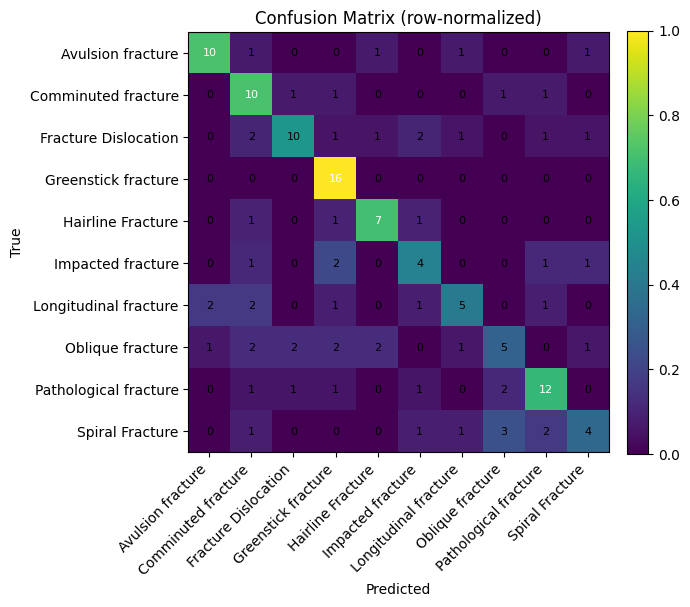

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

# ---------- 1) Collect predictions & targets on test set ----------
model.eval()
all_targets = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        if len(batch) == 3:
            x, y, _ = batch
        else:
            x, y = batch

        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        all_targets.extend(y.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

classes_test = test_ds.classes   # class names, in correct order

print("Confusion matrix will use classes:", classes_test)

# ---------- 2) Plot confusion matrix (matplotlib-only) ----------
cm = confusion_matrix(all_targets, all_preds, labels=list(range(len(classes_test))))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)  # row-normalized

fig, ax = plt.subplots(
    figsize=(1.0 + 0.6 * len(classes_test), 1.0 + 0.6 * len(classes_test))
)
im = ax.imshow(cm_norm, interpolation="nearest")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title("Confusion Matrix (row-normalized)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks(range(len(classes_test)))
ax.set_yticks(range(len(classes_test)))
ax.set_xticklabels(classes_test, rotation=45, ha="right")
ax.set_yticklabels(classes_test)

# annotate cells with raw counts
th = cm_norm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        ax.text(
            j,
            i,
            str(val),
            ha="center",
            va="center",
            color="white" if cm_norm[i, j] > th else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

## CLIP ViT-B-32

In [33]:
"""
This is just a sketch of how you might wire everything together.
You have to fill in your own:
  - model, target_layer
  - CLIP loading (clip_model, preprocess, tokenizer)
  - ref_loader that yields (tensor, label, raw_pil_image)
  - vocabulary list
"""

from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) Load CLIP (example using open_clip, but you can use any CLIP implementation)
import open_clip
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
feature_dim_clip = clip_model.text_projection.shape[1]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [34]:
import json
import requests

# 1) Google Drive file info
file_id = "1zJZ7hvhsx4skp6dqKVbXFyNgqo52ZR2I"
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

# 2) Download the file
out_path = "fracture_xray_descriptors.json"

response = requests.get(download_url)
response.raise_for_status()  # will raise an error if download failed

with open(out_path, "wb") as f:
    f.write(response.content)

print(f"Downloaded to {out_path}")

# 3) Load the JSON and get the descriptors list
with open(out_path, "r") as f:
    data = json.load(f)

vocab_phrases = data["descriptors"]
print(f"Loaded {len(vocab_phrases)} descriptors")
print(vocab_phrases[:10])  # peek at the first few

Downloaded to fracture_xray_descriptors.json
Loaded 272 descriptors
['bone', 'long bone', 'shaft', 'diaphysis', 'metaphysis', 'epiphysis', 'growth plate', 'physis', 'cortex', 'cortical bone']


In [35]:
torch.is_grad_enabled()

True

In [ ]:
token_explainer = TokenGradExplainer(
    student_model=model,
    device=device,
    img_size=224, 
    # num_registers=None   # optional, defaults to config.num_register_tokens (4)
)

estimator = ChannelSemanticEstimator(
    model=model,
    token_explainer=token_explainer,
    clip_model=clip_model,
    clip_preprocess=clip_preprocess,
    device=device,
    feature_dim_clip=feature_dim_clip,
)
estimator.fit(all_train_loader, M=100, max_batches=100)
channel_semantics = estimator.channel_semantics  # [C, D_clip]

heatmap stats: 0.0 1.0 0.2692779004573822


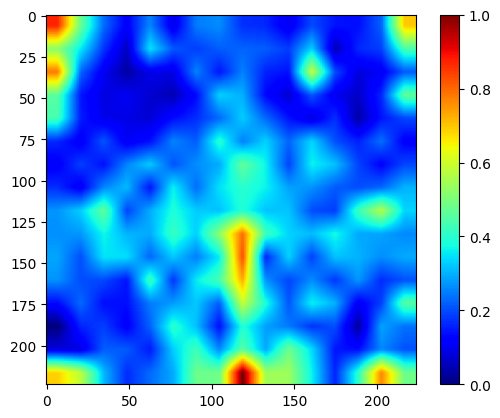

In [43]:
img, y = next(iter(test_loader))
img = img[0:1].to(device)

hm = token_explainer.generate(img, target_class=None)
print("heatmap stats:", hm.min().item(), hm.max().item(), hm.mean().item())
plt.imshow(hm.cpu().numpy(), cmap="jet"); plt.colorbar(); plt.show()

In [ ]:
# 6) Create TextCAM explainer
textcam = TextCAM(
    model=model,
    clip_model=clip_model,
    clip_tokenizer=clip_tokenizer,
    clip_preprocess=clip_preprocess,
    vocab_phrases=vocab_phrases,
    device=device,
    channel_semantics=channel_semantics,
    img_size=224,
    num_registers=4,
)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# --------- helper: de-normalize DINO tensor for display ---------

def denorm_for_display(x, mean=None, std=None):
    """
    x: [3, H, W] tensor normalized for DINO/ImageNet.
    Returns [H, W, 3] numpy array in [0, 1].
    """
    if x.ndim == 4:
        x = x[0]

    if mean is None:
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device)
    else:
        mean = torch.tensor(mean, device=x.device)

    if std is None:
        std = torch.tensor([0.229, 0.224, 0.225], device=x.device)
    else:
        std = torch.tensor(std, device=x.device)

    mean = mean[:, None, None]
    std  = std[:, None, None]

    x = x * std + mean          # undo normalization
    x = x.clamp(0, 1)
    x = x.detach().cpu().permute(1, 2, 0).numpy()  # [H,W,3]
    return x


# --------- main visualization ---------

def visualize_textcam_on_test(
    model,
    token_explainer,
    textcam,
    test_loader,
    class_names,
    device,
    num_images: int = 8,
    top_k: int = 5,
    use_raw_pils: bool = True,
):
    """
    Visualize TextCAM + TokenGrad heatmaps on a few samples from the test set.

    - test_loader: yields either (image_tensor, label) or (image_tensor, label, raw_pil)
      * image_tensor is what you feed into DINO (already processor-transformed)
      * raw_pil (if present) is the original PIL image, used only for pretty display
    """
    model.eval()
    shown = 0

    for batch in test_loader:
        # Support (x, y) and (x, y, raw_pil)
        if len(batch) == 3:
            images, labels, raw_images = batch
        else:
            images, labels = batch
            # No fake PILs here; we will use denorm_for_display instead
            raw_images = [None] * images.size(0)

        B = images.size(0)

        for i in range(B):
            if shown >= num_images:
                return

            img_tensor = images[i:i+1].to(device)   # [1,3,H,W]
            label = labels[i].item()
            raw_img = raw_images[i]

            # ---- 1) prediction ----
            with torch.no_grad():
                logits = model(img_tensor)
            pred_idx = int(logits.argmax(dim=1).item())
            pred_name = class_names[pred_idx] if class_names is not None else str(pred_idx)
            true_name = class_names[label] if class_names is not None else str(label)

            # ---- 2) TokenGrad heatmap ----
            heatmap = token_explainer.generate(img_tensor, target_class=pred_idx)  # [H,W]
            hm = heatmap.detach().cpu().numpy()

            # ---- 3) TextCAM phrases ----
            top_phrases = textcam.explain(
                img_tensor,
                class_idx=pred_idx,
                top_k=top_k,
            )  # List[(phrase, score)]

            # ---- 4) Base image for overlay ----
            if use_raw_pils and (raw_img is not None):
                # Use original image, resized to heatmap size
                raw_resized = raw_img.resize((heatmap.shape[1], heatmap.shape[0]))
                base_img = np.array(raw_resized, dtype=np.float32) / 255.0  # [H,W] or [H,W,3]
            else:
                # De-normalize the DINO input tensor for display
                base_img = denorm_for_display(images[i])  # [H,W,3]

            # ---- 5) Plot ----
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))

            # Original
            if base_img.ndim == 3:
                axes[0].imshow(base_img)
            else:
                axes[0].imshow(base_img, cmap="gray")
            axes[0].set_title(f"Original\ntrue: {true_name}")
            axes[0].axis("off")

            # TokenGrad heatmap
            im2 = axes[1].imshow(hm, cmap="jet")
            axes[1].set_title("TokenGrad heatmap")
            axes[1].axis("off")
            fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

            # Overlay
            if base_img.ndim == 3:
                axes[2].imshow(base_img)
            else:
                axes[2].imshow(base_img, cmap="gray")
            axes[2].imshow(hm, cmap="jet", alpha=0.45)
            axes[2].set_title(f"GT: {true_name}\nPred: {pred_name}")
            axes[2].axis("off")

            # TextCAM phrases as figure title
            phrases_str = "\n".join(
                [f"{j+1}. {p} ({score:.2f})" for j, (p, score) in enumerate(top_phrases)]
            )
            fig.suptitle(
                f"TextCAM explanations (class: {pred_name})\n{phrases_str}",
                fontsize=10,
            )

            plt.tight_layout()
            plt.show()

            shown += 1

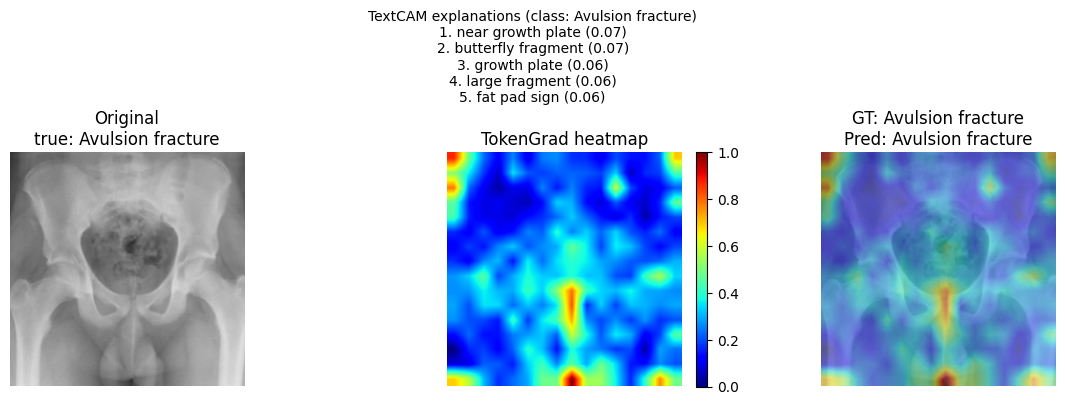

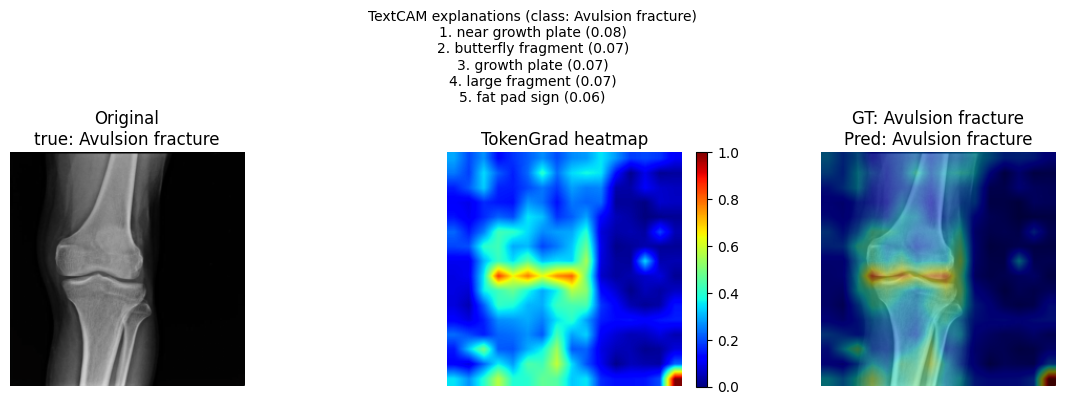

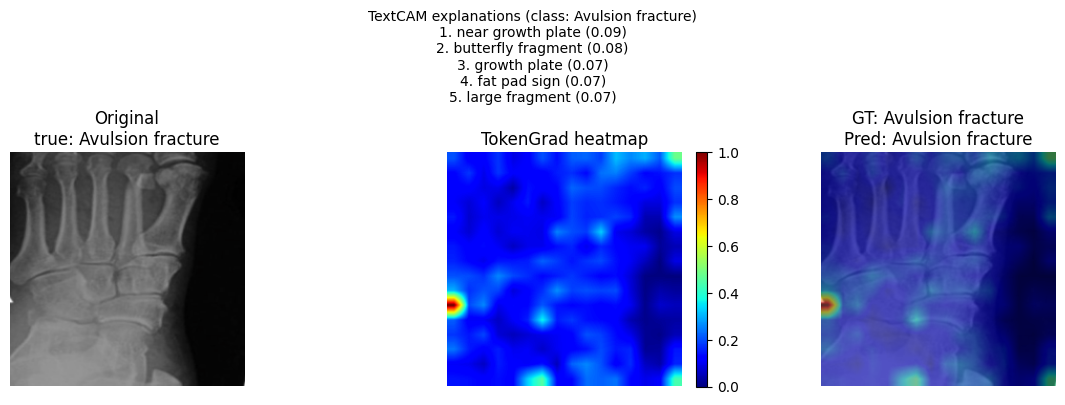

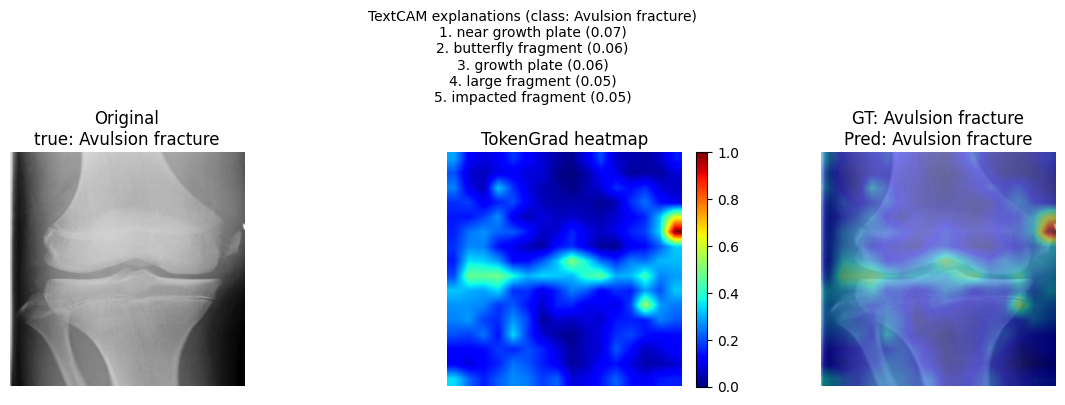

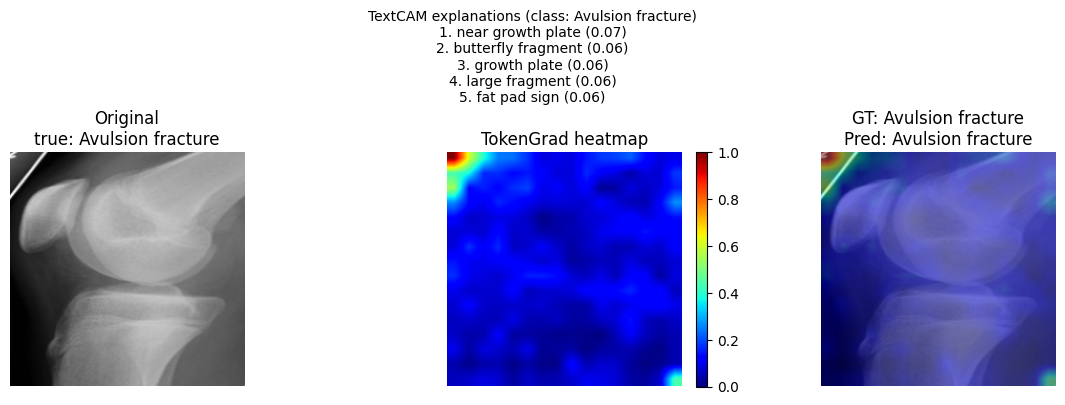

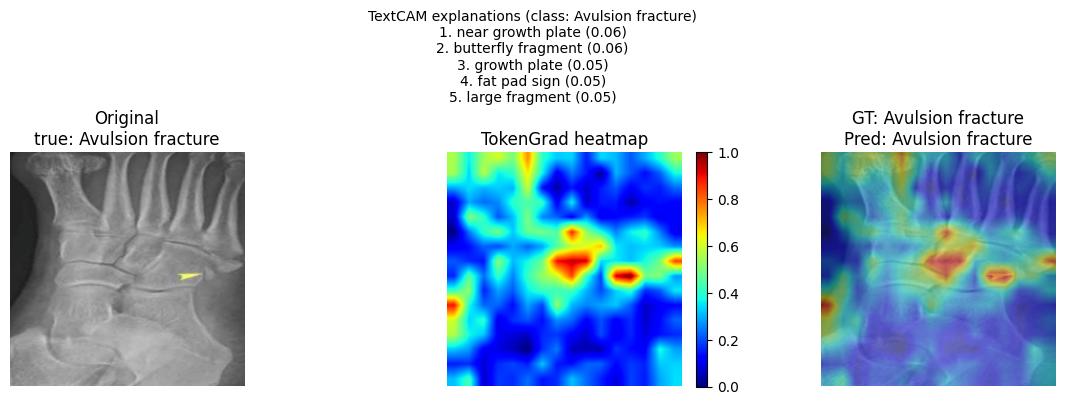

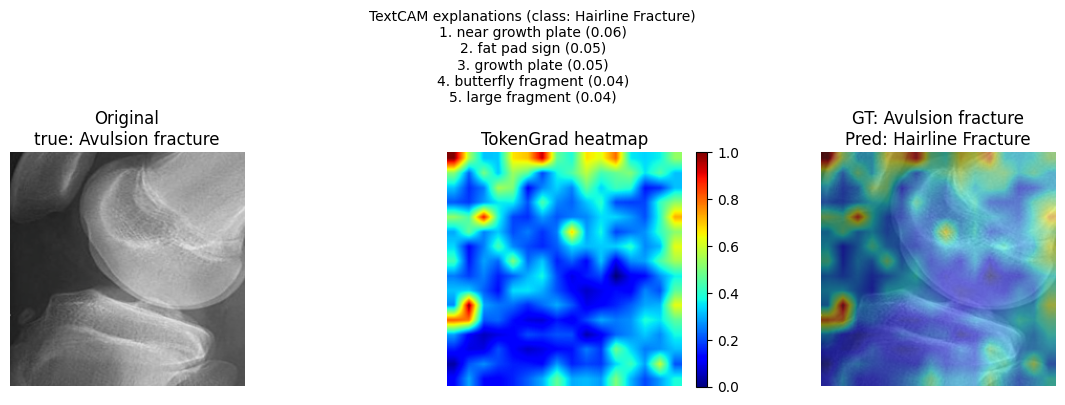

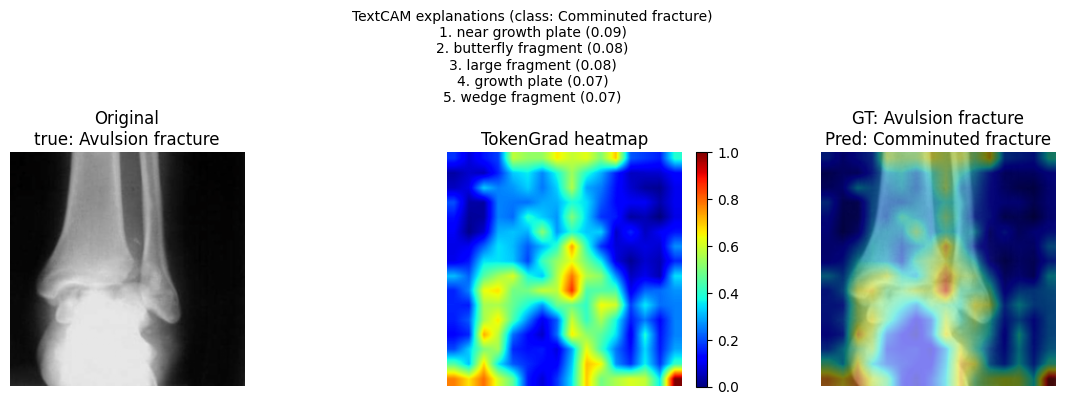

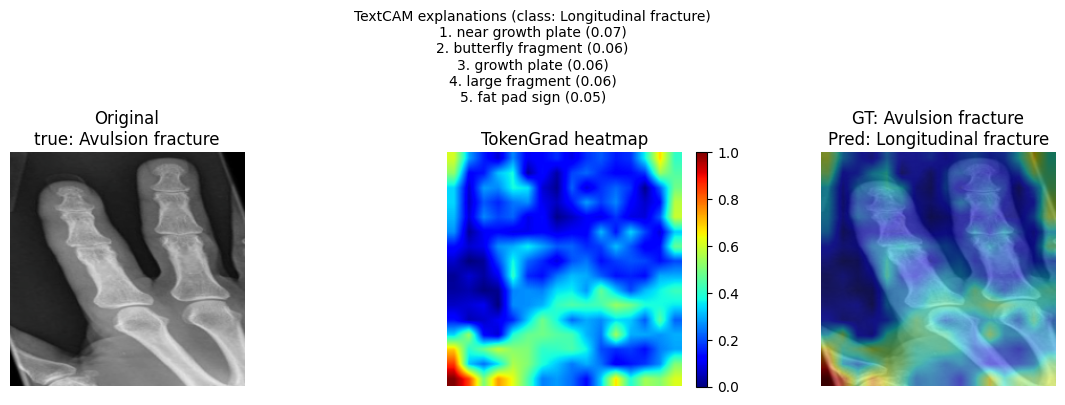

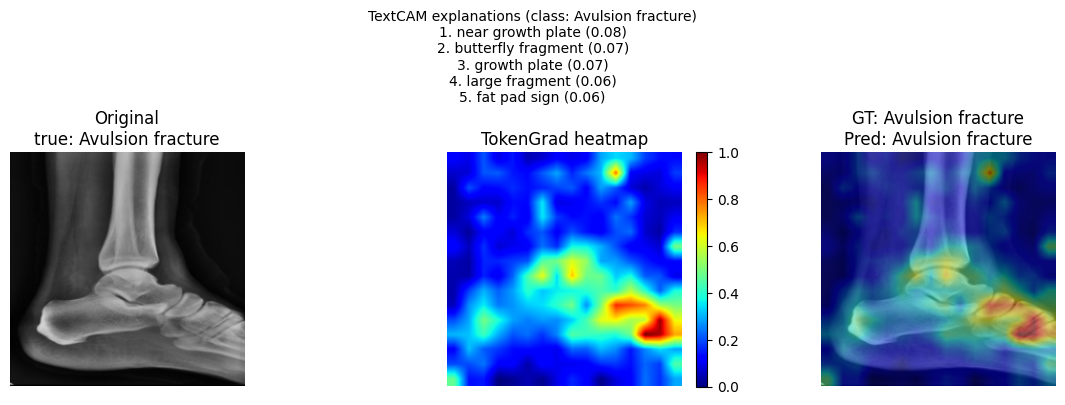

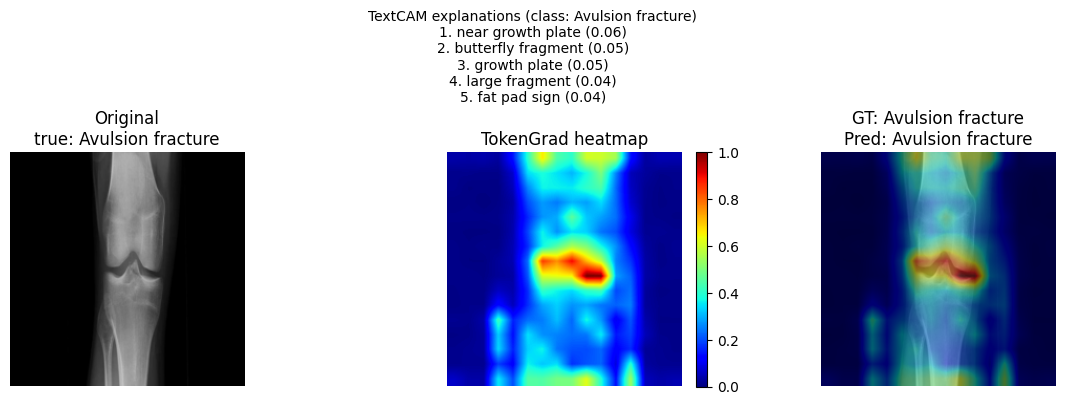

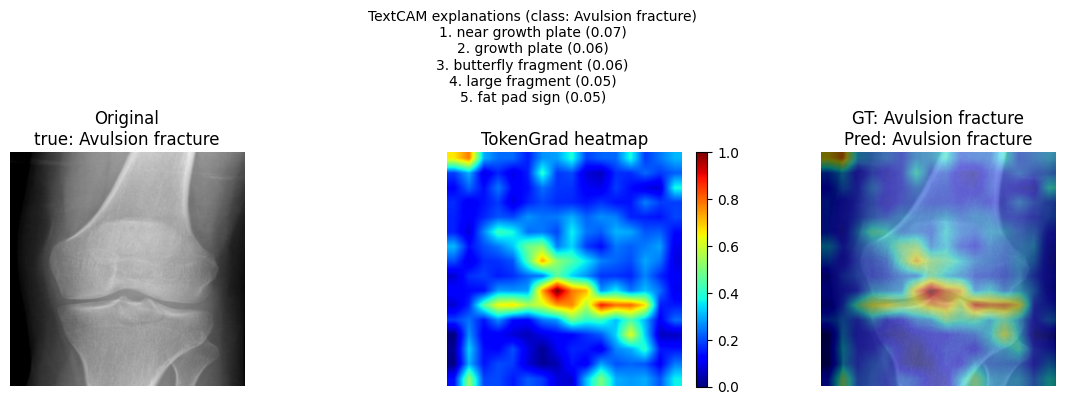

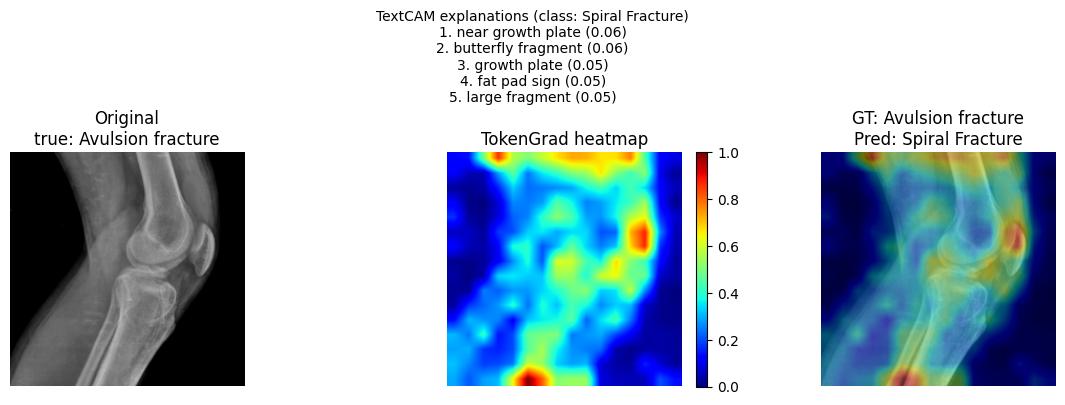

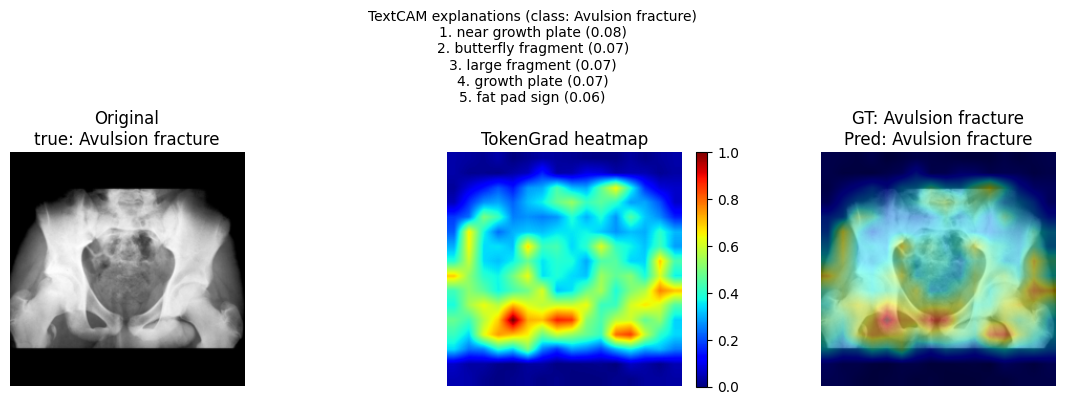

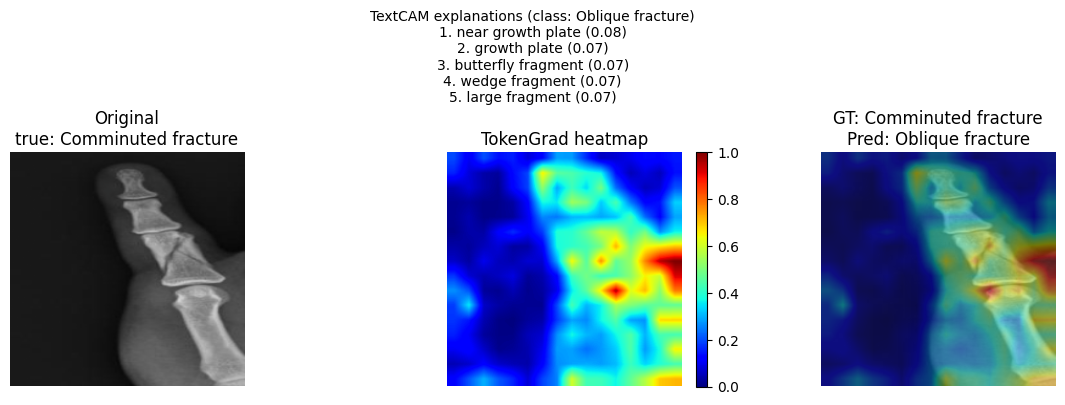

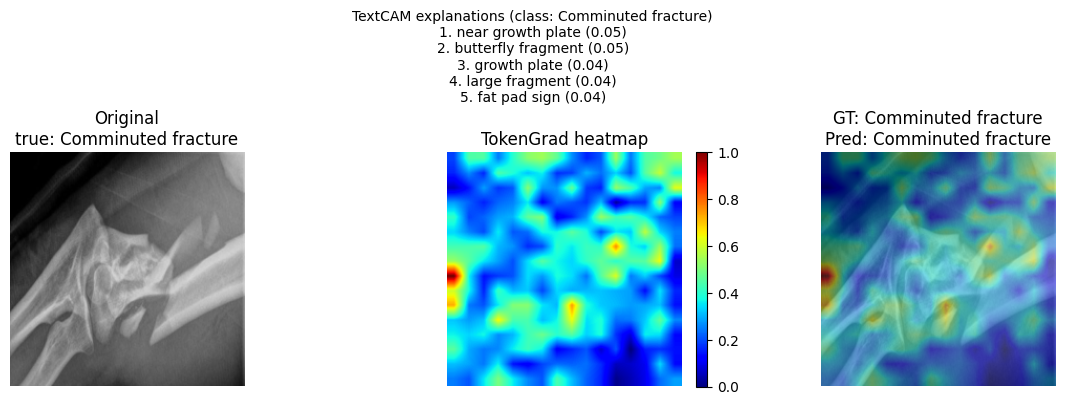

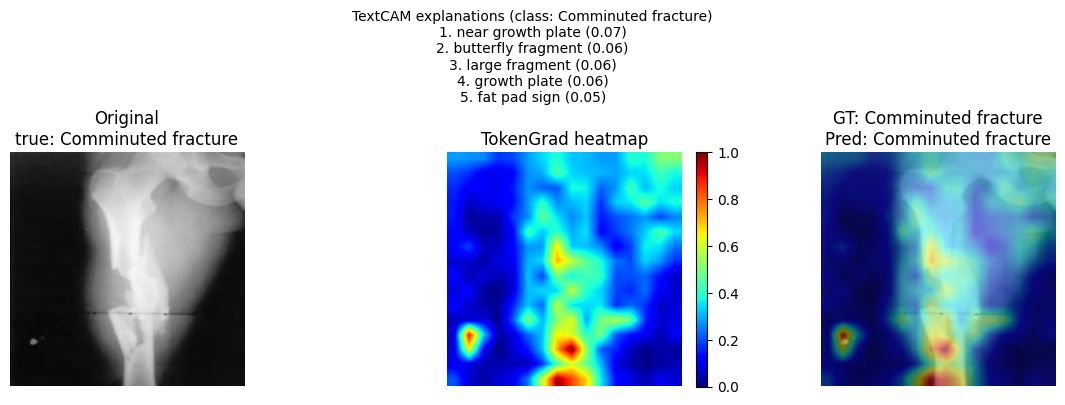

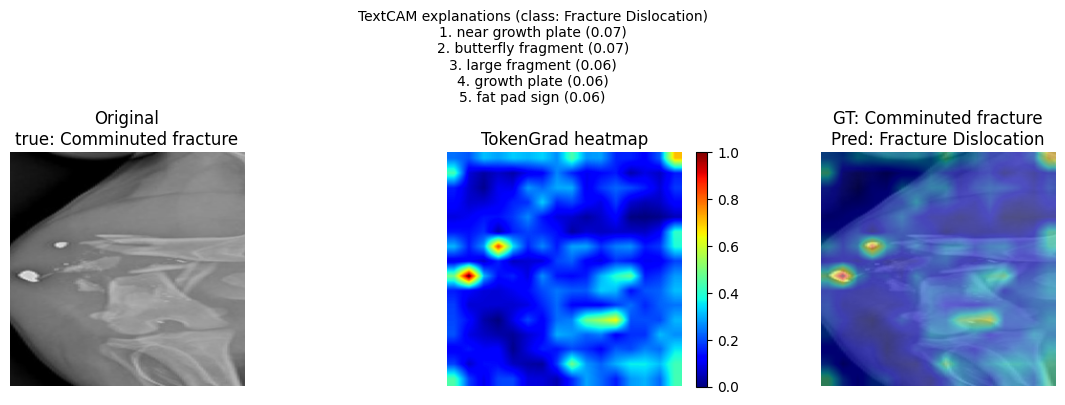

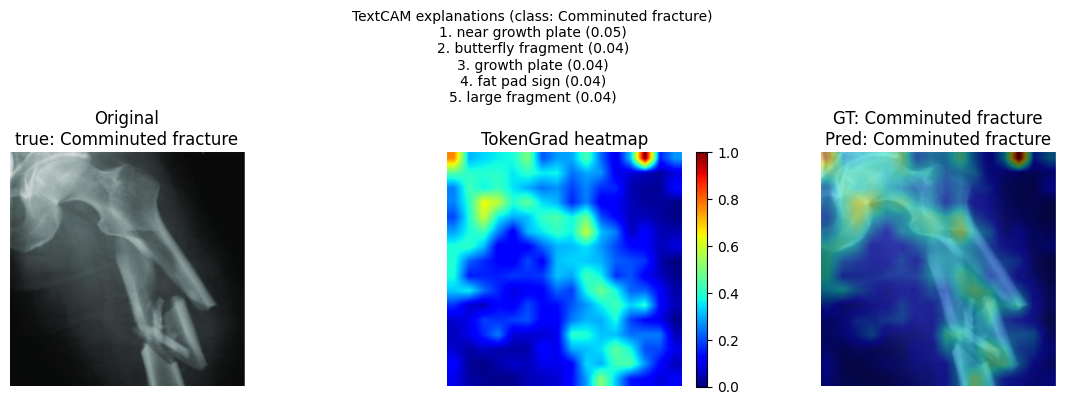

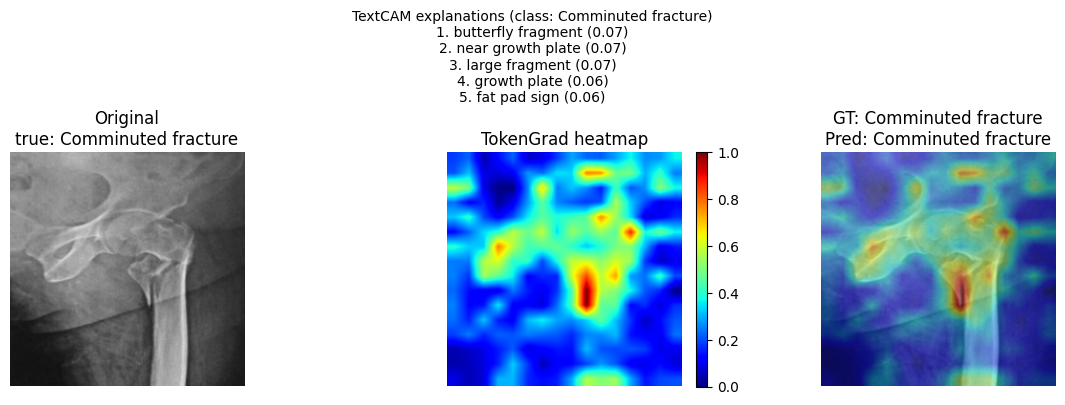

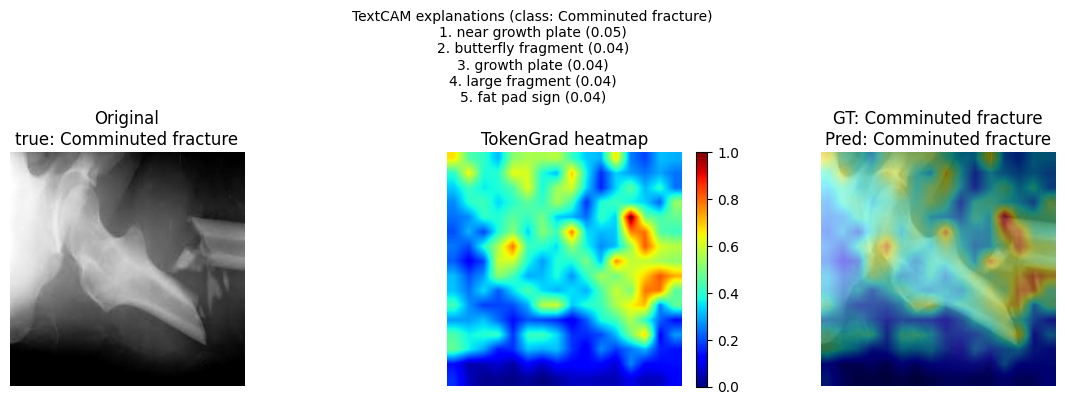

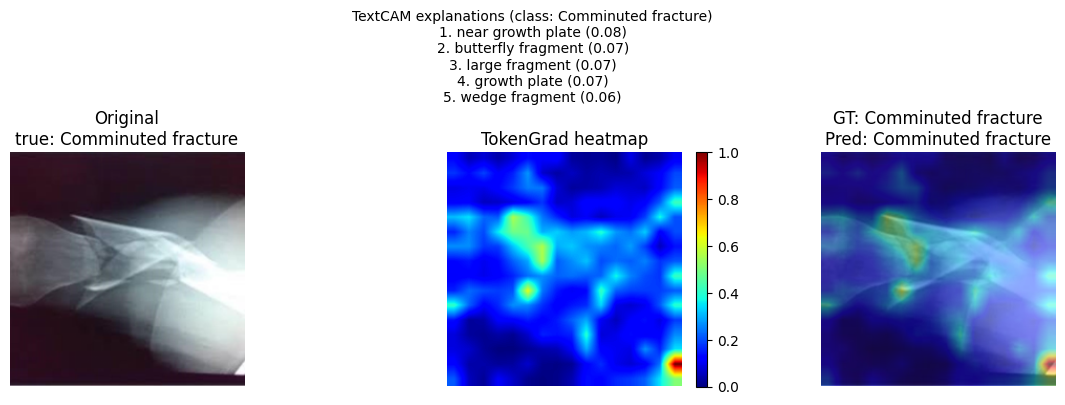

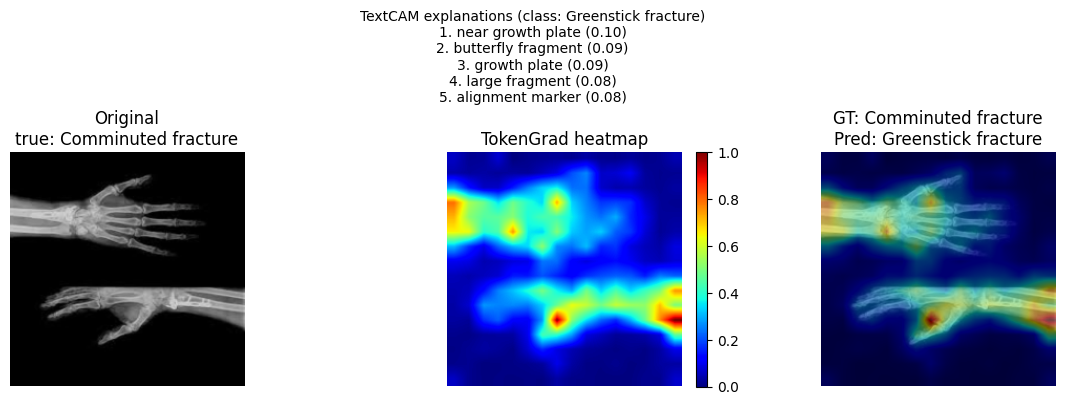

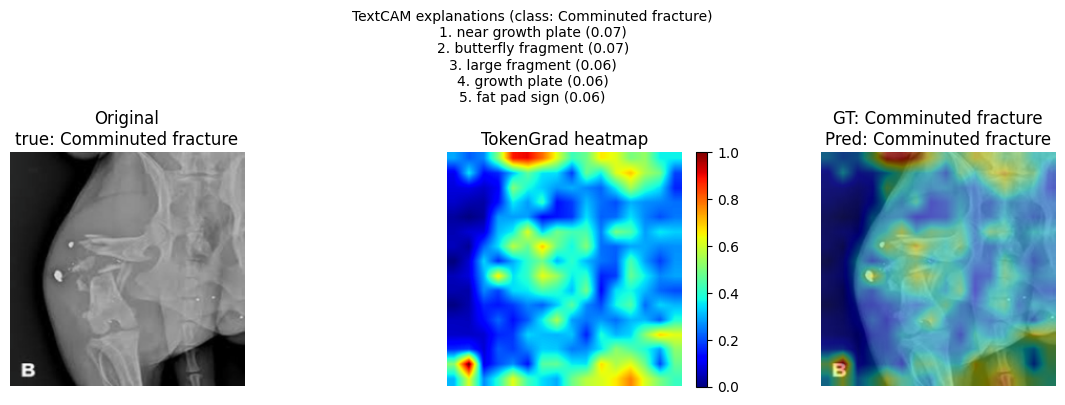

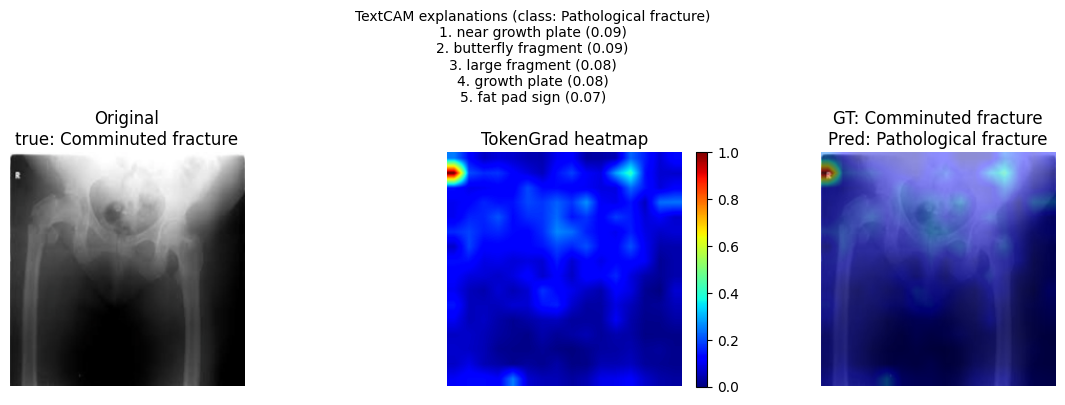

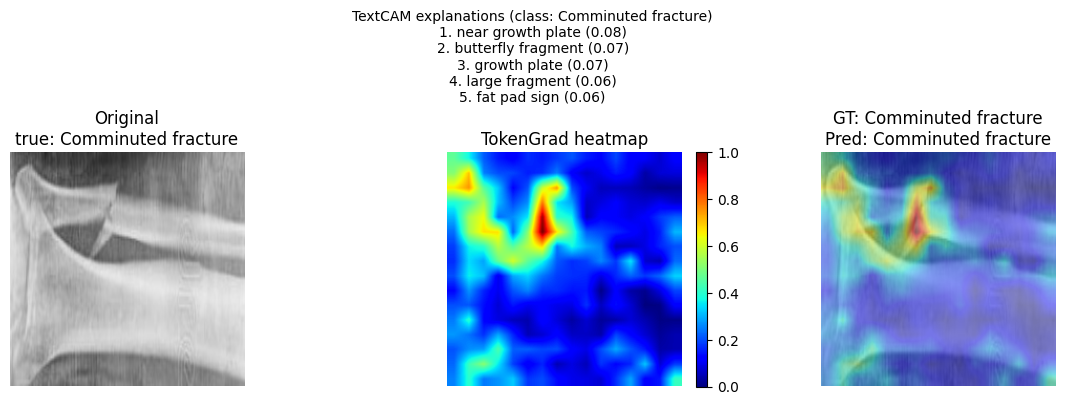

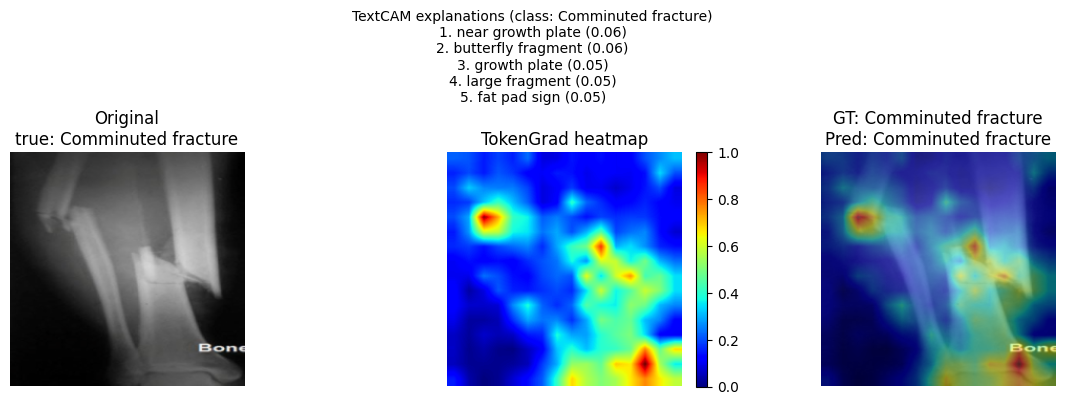

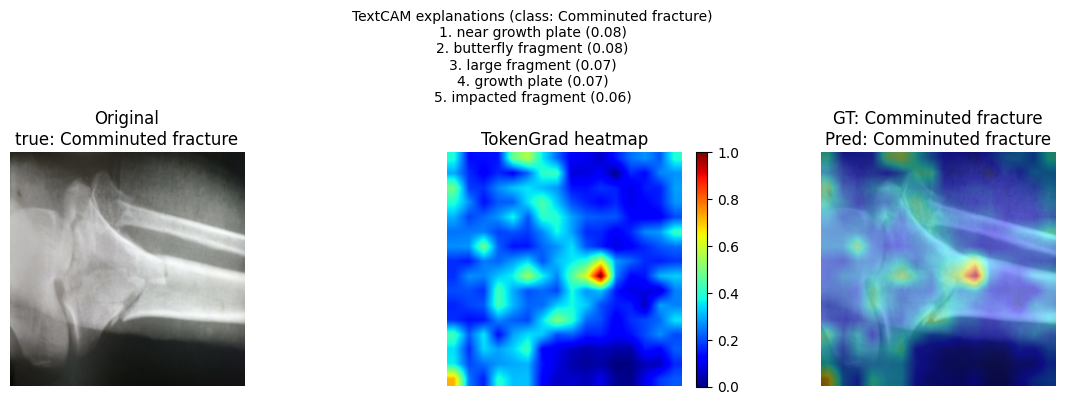

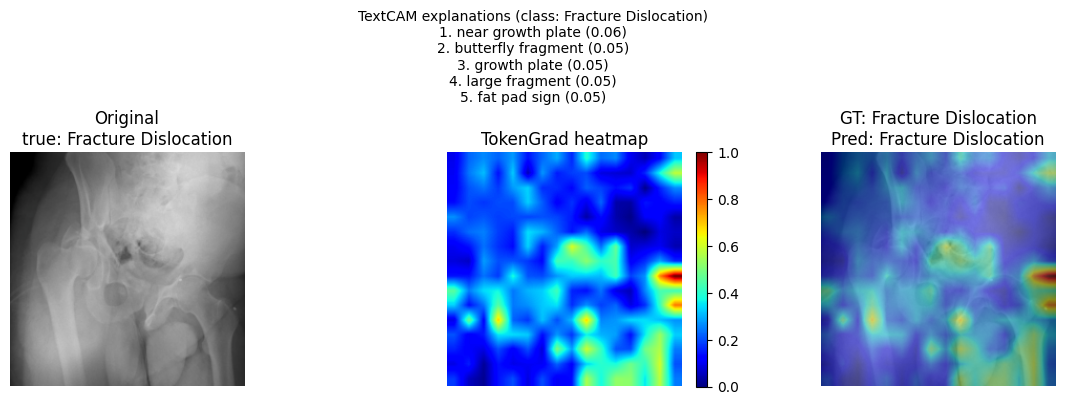

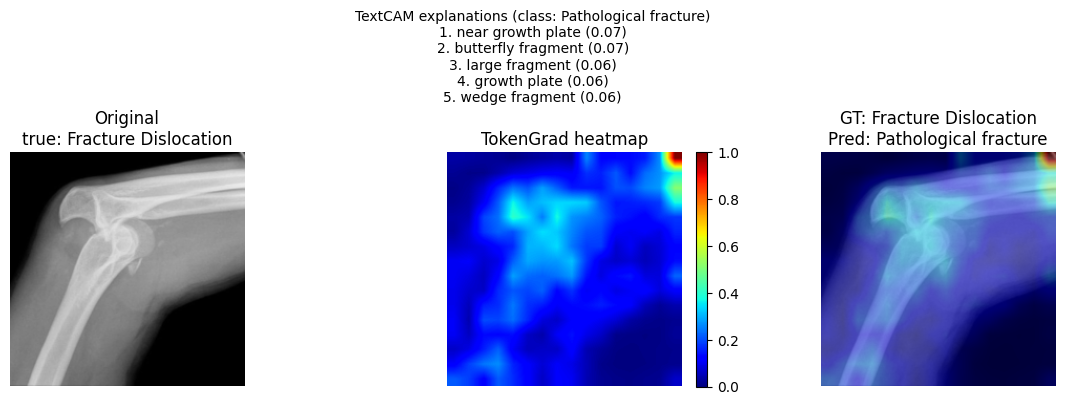

In [50]:
visualize_textcam_on_test(
    model=model,
    token_explainer=token_explainer,
    textcam=textcam,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    num_images=30,
    top_k=5,
)


In [ ]:
# Compare TextCAM vectors for different test images
model.eval()
text_vectors = []
labels = []

for i, (x, y) in enumerate(test_loader):
    x = x.to(device)
    for j in range(min(5, x.size(0))): 
        img = x[j:j+1]
        with torch.no_grad():
            logits = model(img)
            cls = logits.argmax(dim=1).item()
        T = textcam.textcam_vector(img, class_idx=cls)   # [D_clip]
        text_vectors.append(T / T.norm())                # normalize
        labels.append(y[j].item())
    if len(text_vectors) >= 10:
        break

text_vectors = torch.stack(text_vectors, dim=0)  # [N, D_clip]
sims = text_vectors @ text_vectors.T             # [N, N]

print("Pairwise cosine sims between TextCAM vectors:")
print(sims)

Pairwise cosine sims between TextCAM vectors:
tensor([[1.0000, 0.9876, 0.9938, 0.9938, 0.9940, 0.9746, 0.9832, 0.9852, 0.9904,
         0.9897],
        [0.9876, 1.0000, 0.9949, 0.9883, 0.9883, 0.9828, 0.9859, 0.9825, 0.9817,
         0.9862],
        [0.9938, 0.9949, 1.0000, 0.9930, 0.9943, 0.9832, 0.9894, 0.9879, 0.9893,
         0.9906],
        [0.9938, 0.9883, 0.9930, 1.0000, 0.9923, 0.9775, 0.9892, 0.9893, 0.9910,
         0.9891],
        [0.9940, 0.9883, 0.9943, 0.9923, 1.0000, 0.9840, 0.9894, 0.9880, 0.9892,
         0.9933],
        [0.9746, 0.9828, 0.9832, 0.9775, 0.9840, 1.0000, 0.9880, 0.9754, 0.9724,
         0.9813],
        [0.9832, 0.9859, 0.9894, 0.9892, 0.9894, 0.9880, 1.0000, 0.9861, 0.9833,
         0.9885],
        [0.9852, 0.9825, 0.9879, 0.9893, 0.9880, 0.9754, 0.9861, 1.0000, 0.9909,
         0.9934],
        [0.9904, 0.9817, 0.9893, 0.9910, 0.9892, 0.9724, 0.9833, 0.9909, 1.0000,
         0.9887],
        [0.9897, 0.9862, 0.9906, 0.9891, 0.9933, 0.9813, 0.9885